In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
# Utilizing MNIST dataset that is provide by torchvision

from torchvision import datasets, transforms

transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.5,), (0.5,)),
                              ])
trainset = datasets.MNIST('~/.pytorch/MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 53.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 31.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 24.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.89MB/s]


In [3]:
# trainloader wit a batch size of 64 and shuffle true

dataiter = iter(trainloader)
images, labels = next(dataiter)
print(type(images))
print(images.shape)
print(labels.shape)

<class 'torch.Tensor'>
torch.Size([64, 1, 28, 28])
torch.Size([64])


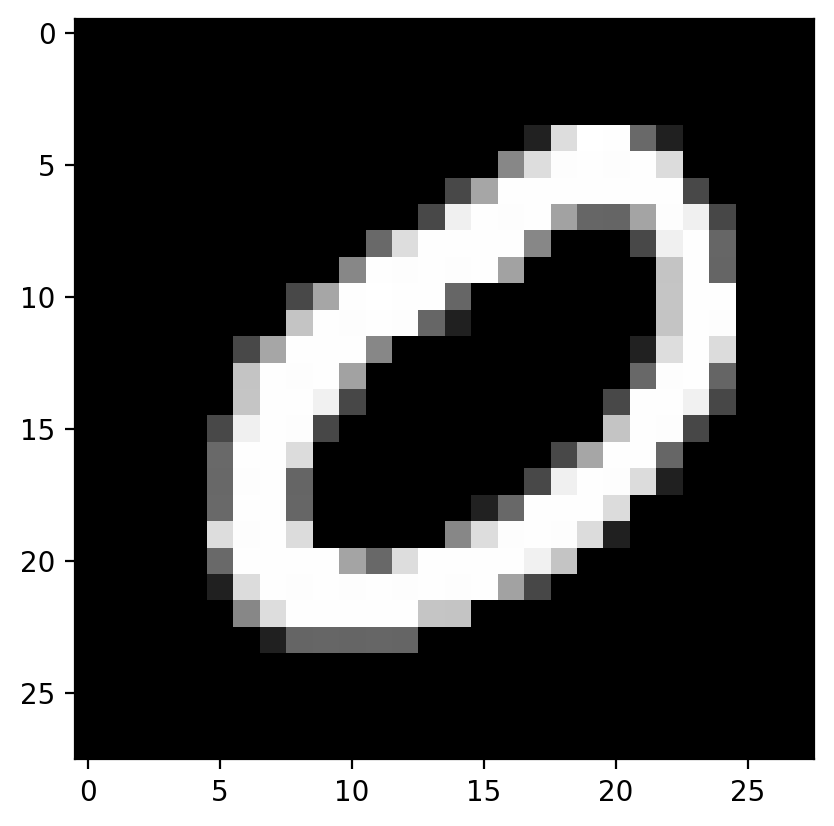

In [9]:
# View on image
plt.imshow(images[0].numpy().squeeze(), cmap='Greys_r')

Goal: Flatten the batch of images. Then build a multi-layer network with 784 input units, 256 hidden units, and 10 output units using random tensors for the weights and biases. Firstly we are going to use a sigmoid activation for the hidden layer. Leave the output layer without an activation, we'll add one (softmax) that gives us a probability distribution next.

In [10]:
# Sigmoid activation function
def activation(x):
  return 1/(1+torch.exp(-x))

# Flatten the input images
inputs = images.view(images.shape[0], -1)

# Create parameters
w1 = torch.randn(784, 256)
b1 = torch.randn(256)

w2 = torch.randn(256, 10)
b2 = torch.randn(10)

# Get output
h = activation(torch.mm(inputs, w1) + b1)
final_h = torch.mm(h, w2) + b2
print(final_h)

tensor([[-6.0868e+00,  1.2433e+01, -1.0748e+01,  7.8620e+00, -1.6960e+01,
          8.2309e+00, -1.1855e+01,  8.6822e+00,  2.1484e+01, -7.3039e+00],
        [-4.0093e+00,  8.0281e+00,  9.6629e-01,  1.3159e+01, -2.3330e+01,
          1.0411e+01, -4.4836e+00,  2.4814e+00,  1.1998e+01, -1.3215e+01],
        [-1.9302e+01,  1.9678e+01, -4.0024e+00,  2.2215e+00, -2.7671e+01,
          1.5901e+00, -1.8482e+01,  4.4460e+00,  4.9250e+00, -1.2211e+01],
        [-1.6943e+01,  1.4979e+01,  2.6341e+00,  3.4062e+00, -2.0226e+01,
          1.0815e+01, -5.3915e+00,  9.8534e+00,  4.2734e+00, -1.0026e+01],
        [-1.3667e+01,  8.4584e+00, -7.4856e+00,  8.2092e+00, -2.0439e+01,
          6.4004e+00, -1.0964e+01,  4.6391e+00,  1.0334e+00, -1.8236e+01],
        [ 8.6487e-01,  1.0994e+01,  8.1873e-01,  3.9147e+00, -2.4050e+01,
          8.6382e+00, -1.1099e+01,  4.9719e-01,  5.8060e+00, -1.3432e+01],
        [-1.4289e+01,  1.8981e+01,  2.3421e+00,  7.3554e+00, -2.3810e+01,
          2.4089e-02, -8.9043e+0

To calculate this probability distribution, we often use the [**softmax** function](https://en.wikipedia.org/wiki/Softmax_function). Mathematically this looks like

$$
\Large \sigma(x_i) = \cfrac{e^{x_i}}{\sum_k^K{e^{x_k}}}
$$

What this does is squish each input $x_i$ between 0 and 1 and normalizes the values to give you a proper probability distribution where the probabilites sum up to one.

Goal: Implement a function softmax that performs the softmax calculation and returns probability distributions for each example in the batch.

In [11]:
# Softmax activation function
def softmax(x):
  return torch.exp(x) / torch.sum(torch.exp(x), dim=1).view(-1, 1)

# Apply softmax to final_h
probabilities = softmax(final_h)

# Check if the probabilities add up to 1
print(probabilities.sum(dim=1))

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000])


Building networks with PyTorch


Goal: Building the same one as above with 784 inputs, 256 hidden units, 10 output units and a softmax output.

In [12]:
from torch import nn

In [13]:
# Must inherit from nn class provided by PyTorch
class SimpleNetwork(nn.Module):

  def __init__(self):
    super().__init__()

    # Inputs to hidden layer linear transformation
    # Output layer : 10 units, one for each digit
    self.hidden = nn.Linear(784, 256)
    self.output = nn.Linear(256, 10)

    # Sigmoid activation and softmax output
    self.sigmoid = nn.Sigmoid()
    self.softmax = nn.Softmax(dim=1)

  def forward(self, x):
    # Pass the input tensor through each of our operations
    x = self.hidden(x)
    x = self.sigmoid(x)

    x = self.output(x)
    x = self.softmax(x)

    return x

In [16]:
# Create the network and look at it's text representation
model = SimpleNetwork()
model

SimpleNetwork(
  (hidden): Linear(in_features=784, out_features=256, bias=True)
  (output): Linear(in_features=256, out_features=10, bias=True)
  (sigmoid): Sigmoid()
  (softmax): Softmax(dim=1)
)

In [19]:
# Utilize the model
model_probabilities = model.forward(inputs)
print(model_probabilities)

tensor([[0.0951, 0.0545, 0.0839, 0.1013, 0.1825, 0.0893, 0.1269, 0.0849, 0.1113,
         0.0703],
        [0.1032, 0.0542, 0.0947, 0.1016, 0.1709, 0.0906, 0.1264, 0.0857, 0.1018,
         0.0711],
        [0.1041, 0.0543, 0.0943, 0.1059, 0.1703, 0.0965, 0.1251, 0.0834, 0.0995,
         0.0667],
        [0.1065, 0.0585, 0.0921, 0.1010, 0.1623, 0.0971, 0.1333, 0.0815, 0.1015,
         0.0662],
        [0.1074, 0.0561, 0.0906, 0.0994, 0.1725, 0.0927, 0.1171, 0.0881, 0.1053,
         0.0708],
        [0.1055, 0.0557, 0.0886, 0.0993, 0.1666, 0.0906, 0.1294, 0.0862, 0.1064,
         0.0717],
        [0.1014, 0.0573, 0.0940, 0.1021, 0.1699, 0.0973, 0.1202, 0.0850, 0.1066,
         0.0661],
        [0.1057, 0.0537, 0.0865, 0.0999, 0.1831, 0.0889, 0.1144, 0.0820, 0.1140,
         0.0717],
        [0.1004, 0.0550, 0.0863, 0.1010, 0.1749, 0.0995, 0.1231, 0.0860, 0.1034,
         0.0704],
        [0.1092, 0.0532, 0.0846, 0.0995, 0.1729, 0.0949, 0.1226, 0.0848, 0.1052,
         0.0732],
        [0

In [20]:
# Check if the probabilities add up to 1
print(model_probabilities.sum(dim=1))

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000], grad_fn=<SumBackward1>)


# Utilizing torch.nn.funtional module to build our network


In [21]:
import torch.nn.functional as F

In [ ]:
# Must inherit from nn class provided by PyTorch
class SimpleNetwork(nn.Module):

  def __init__(self):
    super().__init__()
    self.hidden = nn.Linear(784, 256)             # Inputs to hidden layer linear transformation
    self.output = nn.Linear(256, 10)              # Output layer : 10 units, one for each digit

  def forward(self, x):
    x = F.sigmoid(self.hidden(x))                 # Hidden layer with sigmoid activation
    x = F.softmax(self.output(x))                 # Output layer with softmax activation

    return x

# NEW NETWORK

Goal: Build a network with 784 input units, a hidden layer with 128 units and a ReLU activation, then a hidden layer with 64 units and a ReLU activation, and finally an output layer with a softmax activation as shown above. Using a ReLU activation with the nn.ReLU module or F.relu function.

In [25]:
class NewNetwork(nn.Module):

  def __init__(self):
    super().__init__()

    # Defining the layers: 123 > 64 > 10 units each
    self.layer_1 = nn.Linear(784, 123)
    self.layer_2 = nn.Linear(128, 64)
    self.layer_3 = nn.Linear(64, 10)

  def forward(self, x):
    # Forward pass through the network
    x = F.relu(self.layer_1(x))
    x = F.relu(self.layer_2(x))
    x = F.softmax(self.layer_3(x), dim=1)

    # return output digits
    return x

In [26]:
model = NewNetwork()
model

NewNetwork(
  (layer_1): Linear(in_features=784, out_features=123, bias=True)
  (layer_2): Linear(in_features=128, out_features=64, bias=True)
  (layer_3): Linear(in_features=64, out_features=10, bias=True)
)

In [27]:
# View the weights and biases of the first layer
print(model.layer_1.weight)
print(model.layer_1.bias)

Parameter containing:
tensor([[-0.0008,  0.0082, -0.0152,  ...,  0.0080, -0.0032,  0.0294],
        [-0.0127, -0.0354, -0.0245,  ..., -0.0086,  0.0056,  0.0330],
        [-0.0269,  0.0219, -0.0158,  ..., -0.0249, -0.0062,  0.0306],
        ...,
        [ 0.0194, -0.0049,  0.0216,  ..., -0.0334,  0.0302,  0.0326],
        [ 0.0177,  0.0056, -0.0122,  ..., -0.0095, -0.0035, -0.0204],
        [ 0.0151, -0.0242,  0.0051,  ..., -0.0167,  0.0299, -0.0222]],
       requires_grad=True)
Parameter containing:
tensor([ 0.0024,  0.0293,  0.0029,  0.0258, -0.0254, -0.0158,  0.0302,  0.0251,
         0.0242,  0.0155,  0.0146,  0.0193,  0.0285, -0.0259, -0.0008,  0.0051,
        -0.0130, -0.0077, -0.0175,  0.0260,  0.0288, -0.0295,  0.0079,  0.0173,
         0.0226,  0.0033,  0.0324, -0.0206,  0.0063,  0.0045,  0.0121,  0.0081,
         0.0226,  0.0326,  0.0161,  0.0150, -0.0314,  0.0223,  0.0045, -0.0215,
         0.0248,  0.0286, -0.0348,  0.0223, -0.0265, -0.0294,  0.0198, -0.0352,
        -0.0164

In [ ]:
# Set biases to all zeros
model.layer_1.bias.data.fill_(0)

In [ ]:
# sample from random normal with standard dev = 0.01
model.layer_1.weight.data.normal_(std=0.01)

In [30]:
def view_classify(img, ps, version="MNIST"):
    ''' Function for viewing an image and it's predicted classes.
    '''
    ps = ps.data.numpy().squeeze()

    fig, (ax1, ax2) = plt.subplots(figsize=(6,9), ncols=2)
    ax1.imshow(img.resize_(1, 28, 28).numpy().squeeze())
    ax1.axis('off')
    ax2.barh(np.arange(10), ps)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    if version == "MNIST":
        ax2.set_yticklabels(np.arange(10))
    elif version == "Fashion":
        ax2.set_yticklabels(['T-shirt/top',
                            'Trouser',
                            'Pullover',
                            'Dress',
                            'Coat',
                            'Sandal',
                            'Shirt',
                            'Sneaker',
                            'Bag',
                            'Ankle Boot'], size='small');
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

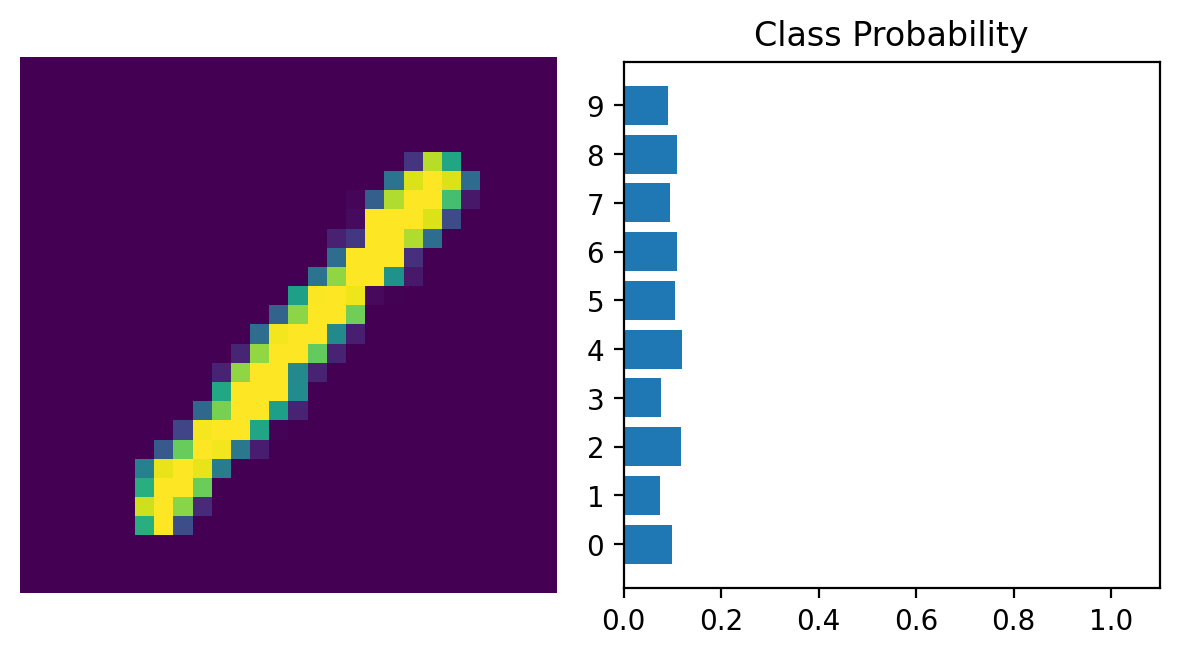

In [33]:
# Grab some data
dataiter = iter(trainloader)
images, labels = next(dataiter)

# Resize images into a 1D vector, new shape is (batch size, color channels, image pixels)
images.resize_(images.shape[0], 1, 784)

# Forward pass through the network
img_idx = 0
ps = model.forward(images[img_idx,:])

img = images[img_idx]
view_classify(img.view(1, 28, 28), ps)

# Utilizing nn.Sequential

In [28]:
# Hyperparameters for our network
input_size = 784
hidden_sizes = [128, 64]
output_size = 10


In [29]:
# Build a feed-forward network
model = nn.Sequential(nn.Linear(input_size, hidden_sizes[0]),
                      nn.ReLU(),
                      nn.Linear(hidden_sizes[0], hidden_sizes[1]),
                      nn.ReLU(),
                      nn.Linear(hidden_sizes[1], output_size),
                      nn.Softmax(dim=1))
print(model)

Sequential(
  (0): Linear(in_features=784, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=10, bias=True)
  (5): Softmax(dim=1)
)


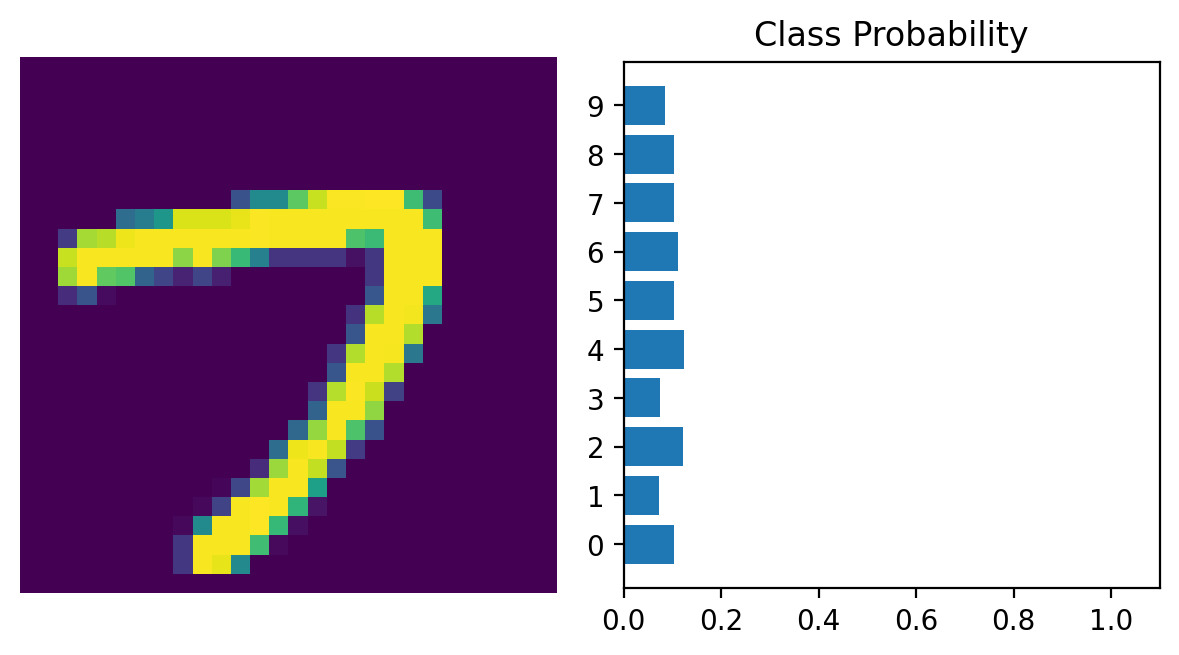

In [32]:
# Forward pass through the network and display output
images, labels = next(iter(trainloader))
images.resize_(images.shape[0], 1, 784)
ps = model.forward(images[0,:])
view_classify(images[0].view(1, 28, 28), ps)

In [34]:
# Get first linear operation and look at the weights
print(model[0])
model[0].weight

Linear(in_features=784, out_features=128, bias=True)


Parameter containing:
tensor([[ 0.0099, -0.0019,  0.0175,  ...,  0.0344,  0.0331, -0.0231],
        [ 0.0332,  0.0092,  0.0341,  ..., -0.0201, -0.0015, -0.0348],
        [-0.0044, -0.0253, -0.0069,  ..., -0.0290,  0.0019, -0.0248],
        ...,
        [ 0.0046,  0.0237,  0.0331,  ...,  0.0298,  0.0202, -0.0250],
        [-0.0013, -0.0193, -0.0226,  ...,  0.0245,  0.0303, -0.0207],
        [-0.0034,  0.0274,  0.0076,  ..., -0.0060, -0.0210, -0.0354]],
       requires_grad=True)

# Using OrderedDict to name the individual layers and operations

In [35]:
from collections import OrderedDict
model = nn.Sequential(OrderedDict([
                      ('layer_1', nn.Linear(input_size, hidden_sizes[0])),
                      ('relu_1', nn.ReLU()),
                      ('layer_2', nn.Linear(hidden_sizes[0], hidden_sizes[1])),
                      ('relu_2', nn.ReLU()),
                      ('output', nn.Linear(hidden_sizes[1], output_size)),
                      ('softmax', nn.Softmax(dim=1))]))
model

Sequential(
  (layer_1): Linear(in_features=784, out_features=128, bias=True)
  (relu_1): ReLU()
  (layer_2): Linear(in_features=128, out_features=64, bias=True)
  (relu_2): ReLU()
  (output): Linear(in_features=64, out_features=10, bias=True)
  (softmax): Softmax(dim=1)
)

In [36]:
# Access layers either by integer or the name
print(model[0])
print(model.layer_1)

Linear(in_features=784, out_features=128, bias=True)
Linear(in_features=784, out_features=128, bias=True)
